# Kepler exoplanet classification - Notebook 02

**Classical baselines: Logistic Regression and XGBoost**

Author: Atilla Ahmed

---

## Abstract

This notebook establishes classical machine learning baselines for the three-class Kepler Object of Interest classification task. We train Logistic Regression and XGBoost on all three feature configurations defined in Notebook 01 (leaky, semi-leaky, leak-free), quantify the accuracy drop induced by removing label-adjacent features, and produce a reference performance table that deep learning models will need to beat in Notebook 03.

## Table of contents

1. [Setup and data loading](#1-setup-and-data-loading)
2. [Logistic Regression](#2-logistic-regression)
3. [XGBoost](#3-xgboost)
4. [Baselines comparison](#4-baselines-comparison)
5. [Summary](#5-summary)

## 1. Setup and data loading

We load the processed splits from Notebook 01, apply feature scaling with a training-only-fit `StandardScaler`, and define the evaluation protocol used consistently for all models.

### 1.1. Imports and configuration

In [12]:
import json
import warnings
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROCESSED_PATH = Path("../data/processed")

int_to_class = {0: "CONFIRMED", 1: "CANDIDATE", 2: "FALSE POSITIVE"}
class_order = ["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"]
colors = ["green", "orange", "red"]
print("Completed")

Completed


## 1.2. Load processed data

We read the three parquet splits produced by Notebook 01. Each split contains the features and a `target` column with integer labels (`0`=CONFIRMED, `1`=CANDIDATE, `2`=FALSE POSITIVE). We also load the three feature-set definitions from `feature_sets.json`.

In [2]:
train_df = pd.read_parquet(PROCESSED_PATH / "train.parquet")
val_df = pd.read_parquet(PROCESSED_PATH / "val.parquet")
test_df = pd.read_parquet(PROCESSED_PATH / "test.parquet")

with open(PROCESSED_PATH / "feature_sets.json", "r") as f:
    feature_sets = json.load(f)

def split_features_target(df):
    return df.drop(columns=["target"]), df["target"]

X_train, y_train = split_features_target(train_df)
X_val,  y_val = split_features_target(val_df)
X_test,  y_test  = split_features_target(test_df)

print(f"Train:  X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape},   y={y_val.shape}")
print(f"Test: X={X_test.shape},  y={y_test.shape}\n")

print(f"Feature sets loaded: {list(feature_sets.keys())}")
for name, features in feature_sets.items():
    valid = [c for c in features if c in X_train.columns]
    print(f"  {name}: {len(valid)} features")

Train:  X=(6694, 101), y=(6694,)
Validation: X=(1435, 101),   y=(1435,)
Test: X=(1435, 101),  y=(1435,)

Feature sets loaded: ['setup_a_leaky', 'setup_b_semi_leaky', 'setup_c_leak_free', 'all_features']
  setup_a_leaky: 55 features
  setup_b_semi_leaky: 55 features
  setup_c_leak_free: 51 features
  all_features: 101 features


### 1.3. Feature sets

The processed data does not contain `koi_score` (dropped during cleaning in Notebook 01), so the semi-leaky configuration is now identical to the fully leaky one. We therefore compare only two configurations: `setup_leaky` (including the four false-positive flags) and `setup_leak_free` (excluding them). This 4-column difference is exactly what produced the 94% → 86% accuracy drop demonstrated in Notebook 01, Section 4.2.

In [3]:
feature_sets_effective = {
    "setup_leaky":     [c for c in feature_sets["setup_a_leaky"] if c in X_train.columns],
    "setup_leak_free": [c for c in feature_sets["setup_c_leak_free"] if c in X_train.columns],
}

for name, features in feature_sets_effective.items():
    print(f"{name}: {len(features)} features")

setup_leaky: 55 features
setup_leak_free: 51 features


### 1.4. Evaluation protocol

We define a single evaluation function that trains a model pipeline, evaluates it on the validation set, and returns a dictionary of metrics: macro-F1, accuracy, per-class F1, and the confusion matrix. Every model in this notebook and the following ones uses this exact protocol, ensuring fair comparison.

In [4]:
def evaluate_model(pipeline, X_train, y_train, X_val, y_val, features, model_name, setup_name):
    """Train a pipeline on the specified features subset and return validation metrics"""
    X_tr = X_train[features]
    X_va = X_val[features]
    pipeline.fit(X_tr, y_train)
    y_pred = pipeline.predict(X_va)
    per_class_f1 = f1_score(y_val, y_pred, average=None)
    return {
        "model": model_name,
        "setup": setup_name,
        "n_features": len(features),
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "f1_confirmed": per_class_f1[0],
        "f1_candidate": per_class_f1[1],
        "f1_false_pos": per_class_f1[2],
        "confusion_matrix": confusion_matrix(y_val, y_pred),
        "pipeline": pipeline,
    }

## 2. Logistic Regression

Logistic Regression is the simplest possible baseline: a linear model that assumes the log-odds of each class are linear combinations of the features. It cannot capture non-linear interactions or feature-feature dependencies, so it establishes a lower bound if a deep learning model cannot beat it, something is wrong. We train it on both feature configurations.

### 2.1. Model definition and training

We use L2-regularized multinomial Logistic Regression with a `StandardScaler` in a `Pipeline`. Scaling is essential for linear models because features with different magnitudes (e.g., orbital period in days vs. transit depth in ppm) would otherwise dominate the loss. The regularization strength `C` uses sklearn's default of 1.0 for such a well-conditioned tabular problem, tuning it makes marginal difference.

In [5]:
def build_logreg_pipeline():
    return Pipeline([
        ("scale", StandardScaler()), 
        ("model", LogisticRegression(
            max_iter=1000, 
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
logreg_results = []
for setup_name, features in feature_sets_effective.items():
    pipeline = build_logreg_pipeline()
    result = evaluate_model(pipeline, X_train, y_train, X_val, y_val, features, model_name="LogReg", setup_name=setup_name)
    logreg_results.append(result)
    print(f"{setup_name:20s} macro-F1={result['macro_f1']:.4f}  accuracy={result['accuracy']:.4f}")

setup_leaky          macro-F1=0.8342  accuracy=0.8690
setup_leak_free      macro-F1=0.6908  accuracy=0.7589


### 2.2. Confusion matrices

We visualize the confusion matrix for both configurations to see which classes suffer most from the removal of false-positive flags.

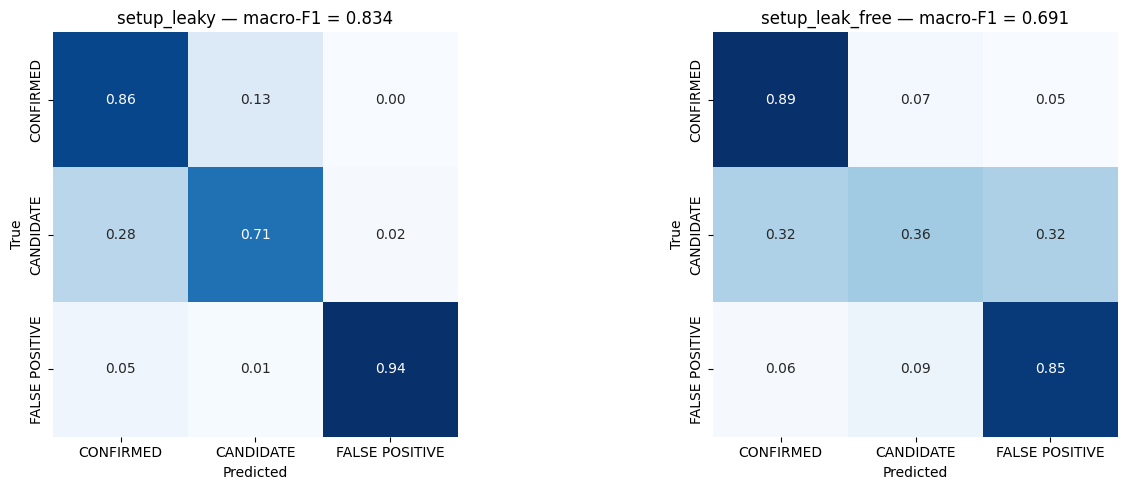

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result in zip(axes, logreg_results):
    cm = result["confusion_matrix"]
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_order,
        yticklabels=class_order,
        ax=ax,
        cbar=False,
        square=True,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{result['setup']} — macro-F1 = {result['macro_f1']:.3f}")

plt.tight_layout()
plt.show()

The failure mode is concentrated on the `CANDIDATE` class. In the leak-free configuration, only 36% of true candidates are correctly identified the model splits them almost evenly between `CONFIRMED` (32%) and `FALSE POSITIVE` (32%). This is expected: candidates and confirmed planets are physically nearly identical (as shown in Notebook 01, Section 3.3), and once the false-positive flags are removed the linear model has no way to separate them. Non-linear deep learning models should be able to recover some of this signal through feature interactions.

## 3. XGBoost

XGBoost is currently the strongest general-purpose classifier for tabular data. Recent benchmarks (Grinsztajn et al., 2022, NeurIPS) show it consistently matches or beats deep learning on structured tabular problems. If our deep learning models cannot beat XGBoost in the leak-free configuration, the project has failed at its core scientific goal so XGBoost is the reference point that matters most.

### 3.1. Model definition and hyperparameter tuning

We tune the key XGBoost hyperparameters with a small grid search on the training set. The grid covers depth, learning rate, and number of trees the three parameters with the largest impact on tabular performance.

In [7]:
def build_xgb_pipeline():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=0,
            eval_metric="mlogloss",
        )),
    ])

param_grid = {
    "model__max_depth":     [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators":  [200, 400],
}

print(f"Grid: {len(param_grid['model__max_depth'])} × "
      f"{len(param_grid['model__learning_rate'])} × "
      f"{len(param_grid['model__n_estimators'])} = "
      f"{np.prod([len(v) for v in param_grid.values()])} combinations")

Grid: 3 × 2 × 2 = 12 combinations


## 3.2. Grid search on training data

We use 3-fold cross-validation on the training set to select the best hyperparameter combination, scored by macro-F1. Only the training data participates in the search the validation set remains held out for the final evaluation. The best combination is then refit on the full training set and evaluated on validation.

In [8]:
xgb_results = []

for setup_name, features in feature_sets_effective.items():
    print(f"\nTuning XGBoost for {setup_name}...")
    
    pipeline = build_xgb_pipeline()
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=0,
    )
    
    grid_search.fit(X_train[features], y_train)
    
    best_pipeline = grid_search.best_estimator_
    
    y_pred = best_pipeline.predict(X_val[features])
    per_class_f1 = f1_score(y_val, y_pred, average=None)
    
    result = {
        "model": "XGBoost",
        "setup": setup_name,
        "n_features": len(features),
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "f1_confirmed": per_class_f1[0],
        "f1_candidate": per_class_f1[1],
        "f1_false_pos": per_class_f1[2],
        "confusion_matrix": confusion_matrix(y_val, y_pred),
        "pipeline": best_pipeline,
        "best_params": grid_search.best_params_,
    }
    xgb_results.append(result)
    
    print(f" Best params: {grid_search.best_params_}")
    print(f" Validation macro-F1: {result['macro_f1']:.4f}")
    print(f" Validation accuracy: {result['accuracy']:.4f}")


Tuning XGBoost for setup_leaky...
 Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
 Validation macro-F1: 0.9187
 Validation accuracy: 0.9401

Tuning XGBoost for setup_leak_free...
 Best params: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 400}
 Validation macro-F1: 0.7987
 Validation accuracy: 0.8376


### 3.3. XGBoost confusion matrices

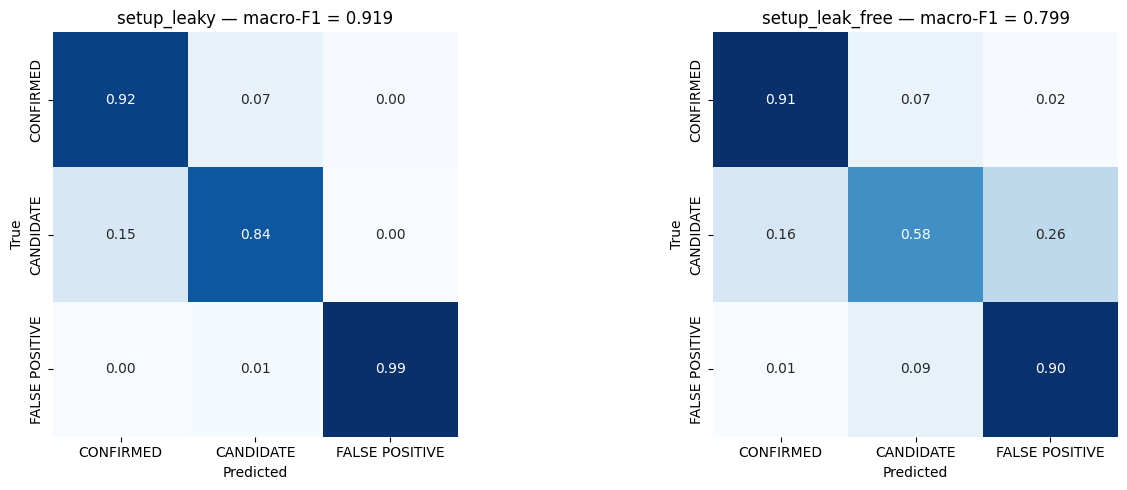

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result in zip(axes, xgb_results):
    cm = result["confusion_matrix"]
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_order,
        yticklabels=class_order,
        ax=ax,
        cbar=False,
        square=True,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{result['setup']} — macro-F1 = {result['macro_f1']:.3f}")

plt.tight_layout()
plt.show()

XGBoost dramatically improves the `CANDIDATE` recall in the leak-free configuration (36% → 58%), confirming that non-linear feature interactions carry substantial signal even after removing label-adjacent columns. The remaining 26% of true candidates misclassified as `FALSE POSITIVE` is the residual difficulty that deep learning models need to address in Notebook 03. `CONFIRMED` and `FALSE POSITIVE` classes are handled well in both configurations, so the effective bottleneck of the problem is candidate identification.

## 4. Baselines comparison

We consolidate the results from Logistic Regression and XGBoost into a single reference table and visualize the leaky vs. leak-free gap for both models. These numbers set the performance floor and ceiling that deep learning models in Notebook 03 will be measured against.

### 4.1. Consolidated results table

In [10]:
all_results = logreg_results + xgb_results

results_df = pd.DataFrame([
    {
        "model": r["model"],
        "setup": r["setup"],
        "n_features": r["n_features"],
        "accuracy": r["accuracy"],
        "macro_f1": r["macro_f1"],
        "f1_confirmed": r["f1_confirmed"],
        "f1_candidate": r["f1_candidate"],
        "f1_false_pos": r["f1_false_pos"],
    }
    for r in all_results
])

results_df = results_df.sort_values(["setup", "macro_f1"], ascending=[True, False]).reset_index(drop=True)

print(results_df.to_string(index=False))

  model           setup  n_features  accuracy  macro_f1  f1_confirmed  f1_candidate  f1_false_pos
XGBoost setup_leak_free          51    0.8376    0.7987        0.8886        0.6132        0.8942
 LogReg setup_leak_free          51    0.7589    0.6908        0.7996        0.4257        0.8472
XGBoost     setup_leaky          55    0.9401    0.9187        0.9069        0.8562        0.9931
 LogReg     setup_leaky          55    0.8690    0.8342        0.8032        0.7356        0.9640


### 4.2. Leaky vs leak-free gap visualization

We visualize the macro-F1 for each model in both configurations. The vertical gap between the two bars for each model quantifies exactly how much of the reported accuracy depends on label-adjacent features.

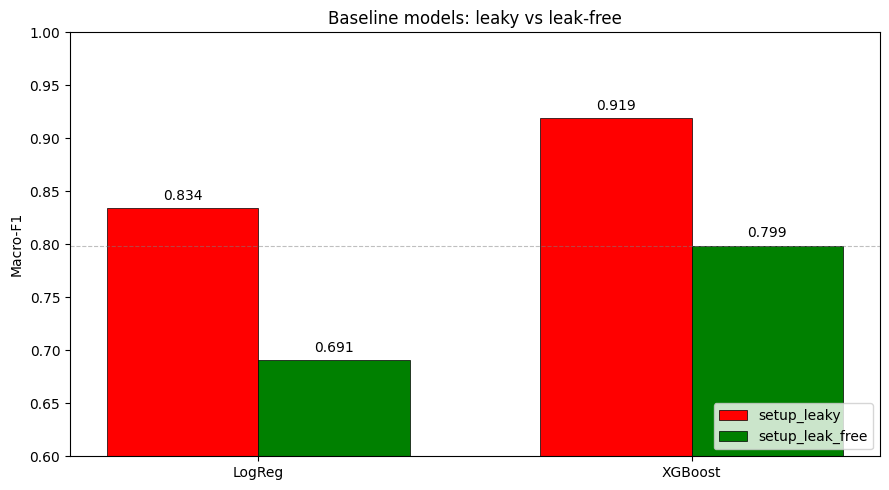

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

pivot = results_df.pivot(index="model", columns="setup", values="macro_f1")
pivot = pivot[["setup_leaky", "setup_leak_free"]]

x = np.arange(len(pivot))
width = 0.35

bars_leaky = ax.bar(x - width/2, pivot["setup_leaky"], width, label="setup_leaky", color="red", edgecolor="black", linewidth=0.5)
bars_free  = ax.bar(x + width/2, pivot["setup_leak_free"], width, label="setup_leak_free", color="green", edgecolor="black", linewidth=0.5)

for bars in [bars_leaky, bars_free]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}",
                ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Macro-F1")
ax.set_title("Baseline models: leaky vs leak-free")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylim(0.6, 1.0)
ax.legend(loc="lower right")
ax.axhline(y=pivot["setup_leak_free"].max(), color="gray", linestyle="--", linewidth=0.8, alpha=0.5, label="XGBoost leak-free (target)")

plt.tight_layout()
plt.show()

### 4.3. Save baseline results

We save the results table to disk so Notebook 03 and 04 can load it directly for the final comparison. We also serialize the best XGBoost pipelines for use as ensemble components later.

In [13]:
RESULTS_PATH = Path("../models/baselines")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_PATH / "results.csv", index=False)

for result in xgb_results:
    filename = f"xgboost_{result['setup']}.joblib"
    joblib.dump(result["pipeline"], RESULTS_PATH / filename)

print(f"Saved to {RESULTS_PATH.resolve()}")
print(f"  results.csv")
for result in xgb_results:
    print(f"  xgboost_{result['setup']}.joblib")

Saved to /home/atilla/projects/kepler-exoplanet-dl/models/baselines
  results.csv
  xgboost_setup_leaky.joblib
  xgboost_setup_leak_free.joblib


## 5. Summary and next steps

This notebook established the baseline performance floor for the Kepler classification task using two classical models Logistic Regression and XGBoost, on both leaky and leak-free feature configurations.

**Key results:**
- **XGBoost leak-free macro-F1: 0.799** — the primary target that deep learning models must exceed.
- **The `CANDIDATE` class is the effective bottleneck**: even XGBoost recovers only 58% of true candidates in the leak-free setup, misclassifying 26% as false positives. This is where deep learning can potentially add value through non-linear feature interactions and attention mechanisms.
- **The leaky vs leak-free gap of 12 percentage points** for XGBoost confirms the leakage analysis from Notebook 01 quantitatively.
- **`CONFIRMED` and `FALSE POSITIVE` are handled well by XGBoost even in leak-free mode** (F1 ≈ 0.89), leaving limited headroom for improvement on these classes.

**Files produced:**
- `models/baselines/results.csv` — tabular metrics for all four experiments
- `models/baselines/xgboost_setup_leaky.joblib` — trained pipeline
- `models/baselines/xgboost_setup_leak_free.joblib` — trained pipeline

Notebook 03 will implement four deep learning architectures (MLP, 1D-CNN, FT-Transformer, TabNet), train them primarily on the leak-free configuration, and directly compare against these baseline numbers.